<a href="https://colab.research.google.com/github/poojya100/6thSem-ML-Lab/blob/main/%E2%80%9C1BM23CS303_Lab_4_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Binary classification

With library

   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      sales   

   salary  
0     low  
1  medium  
2 

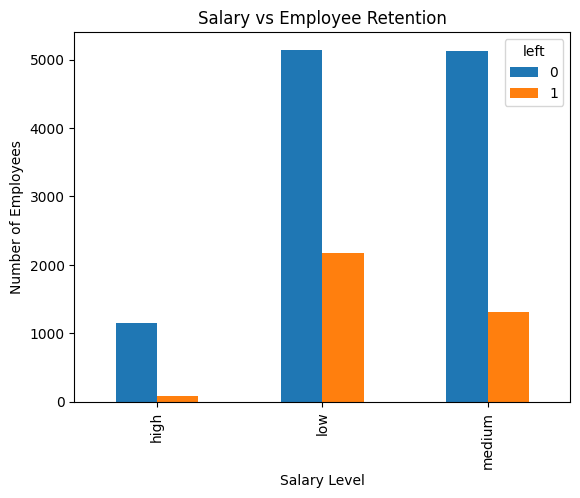

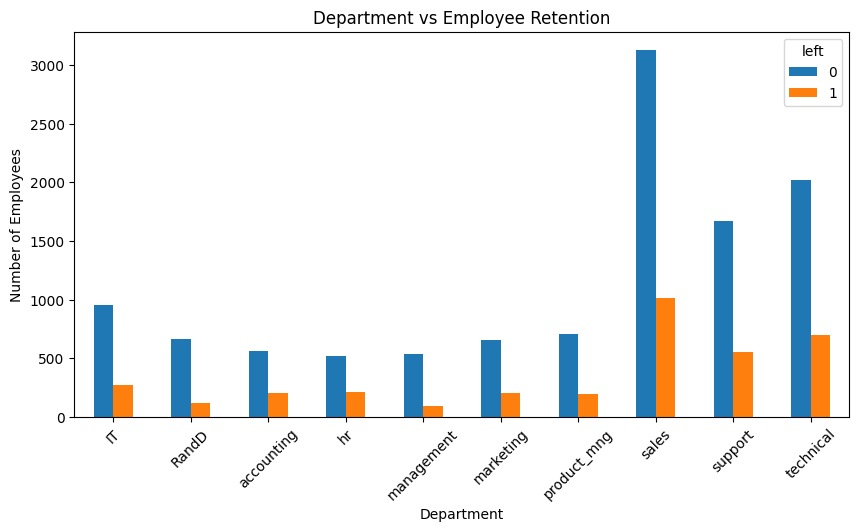

Model Accuracy: 0.7583333333333333


In [3]:
# =========================
# Logistic Regression (Using Library)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("HR_comma_sep.csv")

# ---------------------------
# EDA
# ---------------------------
print(df.head())
print(df.info())
print(df.describe())

# ✅ Correlation only for numeric columns
print(df.select_dtypes(include=np.number).corr())

# ---------------------------
# Salary vs Retention
# ---------------------------
salary_retention = pd.crosstab(df['salary'], df['left'])
salary_retention.plot(kind='bar')
plt.title("Salary vs Employee Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

# ---------------------------
# Department vs Retention
# ---------------------------
dept_retention = pd.crosstab(df['Department'], df['left'])
dept_retention.plot(kind='bar', figsize=(10,5))
plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

# ---------------------------
# Feature Selection
# ---------------------------
features = [
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'salary'
]

X = df[features].copy()   # avoid warning
y = df['left']

# Encode salary (categorical → numeric)
le = LabelEncoder()
X['salary'] = le.fit_transform(X['salary'])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Build Logistic Regression Model
# ---------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

without library

In [4]:
# =========================
# Logistic Regression (Without Library)
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Load dataset
# ---------------------------
df = pd.read_csv("HR_comma_sep.csv")

# ---------------------------
# Feature selection
# ---------------------------
features = [
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'salary'
]

X = df[features].copy()   # avoid SettingWithCopyWarning
y = df['left'].values

# ---------------------------
# Encode salary (categorical → numeric)
# ---------------------------
le = LabelEncoder()
X['salary'] = le.fit_transform(X['salary'])

# Convert to numpy array
X = X.values

# ---------------------------
# Add bias term (column of 1s)
# ---------------------------
X = np.c_[np.ones(X.shape[0]), X]

# ---------------------------
# Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Sigmoid Function
# ---------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ---------------------------
# Gradient Descent
# ---------------------------
def train(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    weights = np.zeros(n)

    for _ in range(epochs):
        z = np.dot(X, weights)
        h = sigmoid(z)
        gradient = np.dot(X.T, (h - y)) / m
        weights -= lr * gradient

    return weights

# ---------------------------
# Train model
# ---------------------------
weights = train(X_train, y_train)

# ---------------------------
# Prediction
# ---------------------------
def predict(X, weights):
    z = np.dot(X, weights)
    probs = sigmoid(z)
    return np.array([1 if i >= 0.5 else 0 for i in probs])

y_pred = predict(X_test, weights)

# ---------------------------
# Accuracy
# ---------------------------
accuracy = np.mean(y_pred == y_test)
print("Manual Model Accuracy:", accuracy)

Manual Model Accuracy: 0.7646666666666667


WITH LIBRARY:

Model Accuracy: 0.9523809523809523


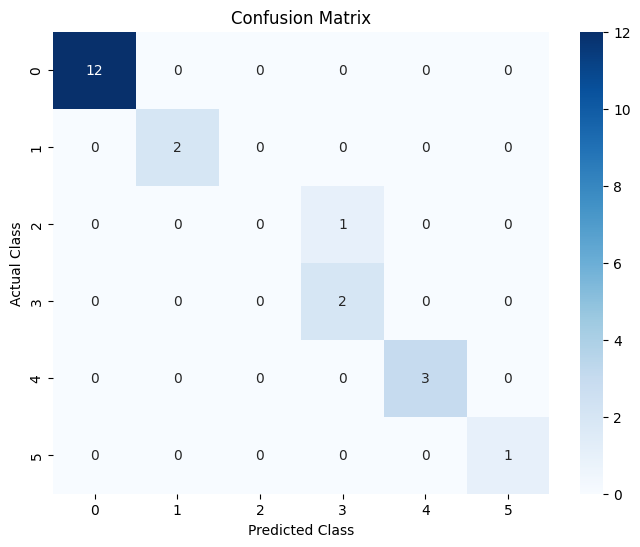

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
zoo = pd.read_csv("zoo-data.csv")
class_info = pd.read_csv("zoo-class-type.csv")

# Drop animal_name column (not useful for prediction)
zoo = zoo.drop(columns=["animal_name"])

# Features and target
X = zoo.drop(columns=["class_type"])
y = zoo["class_type"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Logistic Regression Model
model = LogisticRegression(max_iter=2000)   # ✅ Removed multi_class parameter
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

without library

Manual Model Accuracy: 0.9047619047619048


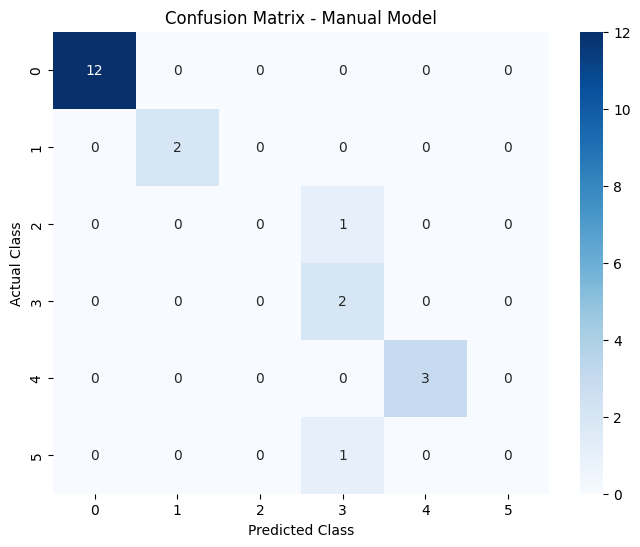

In [6]:
# ==========================================
# Zoo Dataset - Manual Multiclass Logistic Regression
# (Fixed OneHotEncoder Error)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score

# ---------------------------
# Load Data
# ---------------------------
zoo = pd.read_csv("zoo-data.csv")

# Drop animal_name column
zoo = zoo.drop(columns=["animal_name"])

# Separate features and target
X = zoo.drop(columns=["class_type"]).values
y = zoo["class_type"].values

# ---------------------------
# One-hot encode target (FIXED LINE)
# ---------------------------
encoder = OneHotEncoder(sparse_output=False)   # ✅ Updated parameter
y_onehot = encoder.fit_transform(y.reshape(-1,1))

# ---------------------------
# Train-Test Split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42
)

# Add bias column
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# ---------------------------
# Softmax Function
# ---------------------------
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ---------------------------
# Training Function
# ---------------------------
def train(X, y, lr=0.01, epochs=2000):
    m, n = X.shape
    k = y.shape[1]
    weights = np.zeros((n, k))

    for _ in range(epochs):
        z = np.dot(X, weights)
        h = softmax(z)
        gradient = np.dot(X.T, (h - y)) / m
        weights -= lr * gradient

    return weights

weights = train(X_train, y_train)

# ---------------------------
# Prediction
# ---------------------------
def predict(X, weights):
    z = np.dot(X, weights)
    probs = softmax(z)
    return np.argmax(probs, axis=1)

y_pred = predict(X_test, weights)
y_test_labels = np.argmax(y_test, axis=1)

# ---------------------------
# Accuracy
# ---------------------------
accuracy = accuracy_score(y_test_labels, y_pred)
print("Manual Model Accuracy:", accuracy)

# ---------------------------
# Confusion Matrix
# ---------------------------
cm = confusion_matrix(y_test_labels, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix - Manual Model")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()